In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df=pd.read_csv("/Users/mac/Desktop/Machine Learning/ai-roadmap/content/ml/supervised/04 regularisation/data/california_housing.csv")

In [18]:
#Preview
print("First 5 rows:", df.head())
print("Information:", df.info())
print("Summary:", df.describe())

First 5 rows:    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Populat

In [19]:
#checking missing values
missing_per=df.isnull().mean()*100
print("\nPercentage of missing values in each column:")
print(missing_per)


Percentage of missing values in each column:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
dtype: float64


In [20]:
# drop columns with more than 80% missing values
columns_to_drop=missing_per[missing_per>80].index
df.drop(columns=columns_to_drop, inplace=True)

In [21]:
#drop rows with missing values is less than 5%
low_missing_cols = missing_per[(missing_per > 0) & (missing_per < 5)].index
df.dropna(subset=low_missing_cols, inplace=True)

In [22]:
print("\nColumns with unusual distribution or outliers:")
for col in df.columns:
    print(f"Number of unique values in {col}: {df[col].nunique()}")


Columns with unusual distribution or outliers:
Number of unique values in MedInc: 12928
Number of unique values in HouseAge: 52
Number of unique values in AveRooms: 19392
Number of unique values in AveBedrms: 14233
Number of unique values in Population: 3888
Number of unique values in AveOccup: 18841
Number of unique values in Latitude: 862
Number of unique values in Longitude: 844
Number of unique values in MedHouseVal: 3842


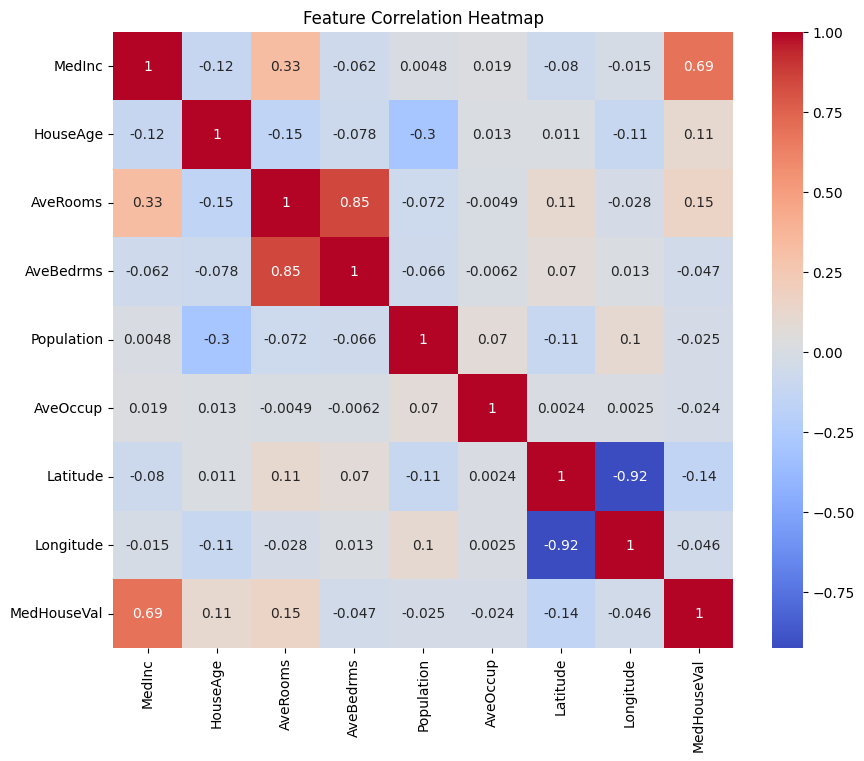

In [23]:
#Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [24]:
#Splitting Data
X=df.drop("MedHouseVal", axis=1)
y=df["MedHouseVal"]

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42)

In [25]:
#Sacel After splitting
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [26]:
#Baseline: Linear Regression
lin_reg=LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_test_pred_lr=lin_reg.predict(X_test_scaled) 

mse_lr=mean_squared_error(y_test, y_test_pred_lr)
r2_lr=r2_score(y_test, y_test_pred_lr)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MSE: 0.5558915986952444
Linear Regression R2: 0.5757877060324508


## Ridge Regression (L2 Regularization) ##

In [27]:
alphas=np.logspace(-3, 3, 50)

best_alpha=None
best_mse=float("inf")
best_model=None 

# Loop over all alpha values
for alpha in alphas:
    model=Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    
    y_pred=model.predict(X_test_scaled)
    mse_l2=mean_squared_error(y_test, y_pred)
    
    #Select best model (lower MSE)
    if mse_l2<best_mse:
        best_mse=mse_l2
        best_alpha=alpha
        best_model=model

In [28]:
#Final evelution
y_pred_ridge=best_model.predict(X_test_scaled) #type:ignore
r2_ridge=r2_score(y_test, y_pred_ridge)

print("Best alpha (manual):", best_alpha)
print("Ridge MSE:", best_mse)
print("Ridge R2:", r2_ridge)

Best alpha (manual): 244.205309454865
Ridge MSE: 0.5522374057550283
Ridge R2: 0.5785762957024647


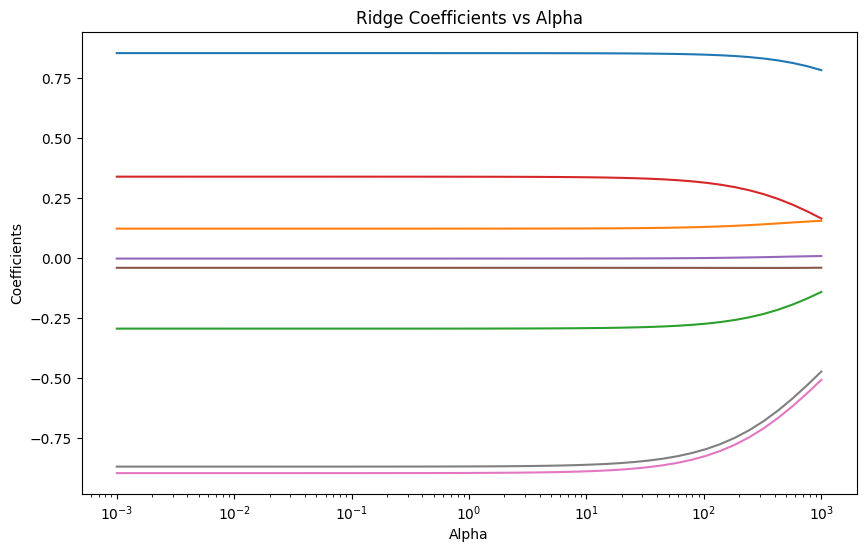

In [29]:
#Ridge Coefficient Plot
coefs=[]

for a in alphas:
    model=Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_)
    
plt.figure(figsize=(10,6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("Ridge Coefficients vs Alpha")
plt.show()

## Lasso Regression (L1 Regularization) ##

In [30]:
best_alpha_l1 = None
best_mse_l1 = float("inf")
best_model_l1 = None

for alpha in alphas:
    model_l1=Lasso(alpha=alpha, max_iter=10000)
    model_l1.fit(X_train_scaled, y_train)
    
    y_pred=model_l1.predict(X_test_scaled)
    mse_l1=mean_squared_error(y_test, y_pred)
    
    if mse_l1<best_mse_l1:
        best_mse_l1=mse_l1
        best_alpha_l1=alpha
        best_model_l1=model_l1

In [31]:
# Final evaluation
y_pred_lasso = best_model_l1.predict(X_test_scaled)   #type:ignore
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Best alpha (manual Lasso):", best_alpha_l1)
print("Lasso MSE:", best_mse_l1)
print("Lasso R2:", r2_lasso)

Best alpha (manual Lasso): 0.009540954763499945
Lasso MSE: 0.548283869022966
Lasso R2: 0.5815933207669369


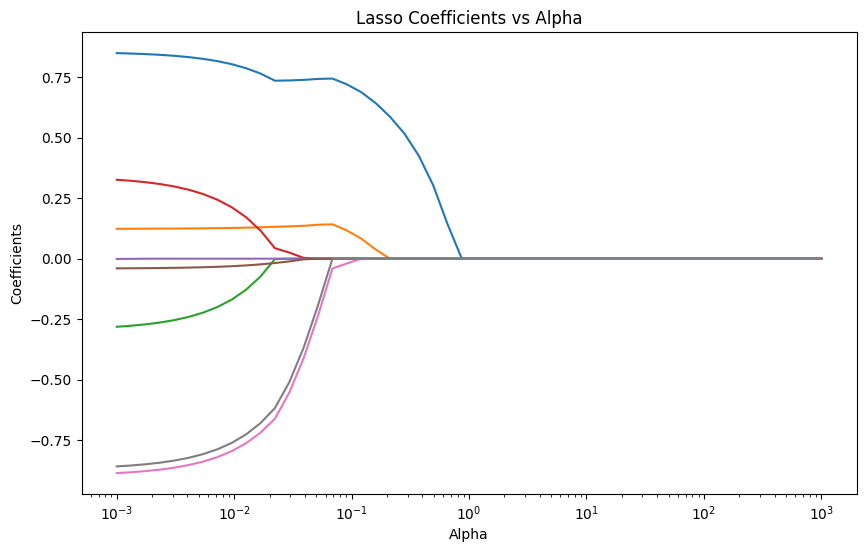

In [32]:
# Lasso Coefficient Plot
coefs_lasso = []

for a in alphas:
    model_l1 = Lasso(alpha=a, max_iter=10000)
    model_l1.fit(X_train_scaled, y_train)
    coefs_lasso.append(model_l1.coef_)

plt.figure(figsize=(10,6))
plt.plot(alphas, coefs_lasso)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("Lasso Coefficients vs Alpha")
plt.show()

In [33]:
#Models Comparison
print("\n--- Model Comparison ---")

print(f"Linear Regression -> MSE: {mse_lr:.4f}, R2: {r2_lr:.4f}")
print(f"Ridge Regression  -> MSE: {best_mse:.4f}, R2: {r2_ridge:.4f}")
print(f"Lasso Regression  -> MSE: {best_mse_l1:.4f}, R2: {r2_lasso:.4f}")

# Count non-zero coefficients (Lasso feature selection)
non_zero_lasso = np.sum(best_model_l1.coef_ != 0) #type:ignore
print("Non-zero coefficients (Lasso):", non_zero_lasso)


--- Model Comparison ---
Linear Regression -> MSE: 0.5559, R2: 0.5758
Ridge Regression  -> MSE: 0.5522, R2: 0.5786
Lasso Regression  -> MSE: 0.5483, R2: 0.5816
Non-zero coefficients (Lasso): 7


In [3]:
np.zeros(7)

array([0., 0., 0., 0., 0., 0., 0.])